[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Imsharad/ghl-support-slm/blob/v2/notebooks/v2_colab_run.ipynb)

> **Post-run note, added after execution (2026-09-08 04:30 IST). Cell outputs below are untouched.**
>
> This is the executed record of the v2 training run that produced the scored model: free Colab T4, session started 02:12 IST, notebook executed top to bottom by `jupyter nbconvert --execute` from 02:14 IST, git sha `33bdbbd`. Training (cell 8) and the curve-and-gate cell (cell 9) ran clean: 500 steps, 4,832 s, peak 2.94 GB, `check_run.py` PASS.
>
> Two cells errored, neither touching the model, both fixed in the source notebook at commit `77f6f1e`:
> - **Cell 7, smoke run:** `cap 64 leaves no room for corpus rows beside 206 admission rows`. The 64-row smoke cap could not exempt the admission rows; the cap routine now falls back to a uniform cap below the admission count. The smoke proof had passed on this VM earlier that night on the same code without admission rows (resume proof, max abs diff 0.00177).
> - **Cell 10, dev answers:** `ModuleNotFoundError: No module named 'eval'`; the eval runner subprocess needed the repo root on `PYTHONPATH`. The dev answers were regenerated on this same VM at 04:00 to 04:31 IST with the fixed command; the log is appended as the last cell, and the files are in the run zip's companion directory.
>
> A first Colab VM had been reclaimed by the free tier at 02:10 IST at step ~190 of an identical run; this is the second, complete run. The Mac insurance run was stopped at step 325 once this one was gated (decision 14).


# GoHighLevel support SLM, v2: QLoRA on Qwen2.5-1.5B-Instruct, free T4

v1 of this project fine-tuned Qwen2.5-1.5B-Instruct on the Bitext customer-support corpus and lost a blind evaluation: the cleaner had thrown away every row that admits a missing fact, so the tuned model learned the corpus voice and stopped saying "I do not have that". v2 changes the data and nothing else: placeholders are substituted with neutral phrases instead of rejecting the row, and 340 synthetic admission rows are appended to train. Base model, QLoRA recipe, prompt, decoding, rubric and judge protocol are frozen.

This notebook is the v2 training run. Top to bottom on a free T4 it takes about 1.5 hours and produces `train/runs/v2-t4/`: the adapter checkpoints, `loss.csv`, `curves.png`, per-checkpoint dev answers and a gate report. Scoring stays on the sealed Mac path (Q8 GGUF through Ollama), the same pipeline that scored v1.

Repo: [github.com/Imsharad/ghl-support-slm](https://github.com/Imsharad/ghl-support-slm), branch `v2`. Plan and decisions: `docs/plans/V2_PLAN.md`, `docs/v2/PLAN_DECISIONS.md`.

## 1. Runtime

In [1]:
import os, subprocess, time, json, shutil
os.environ.update(HF_HUB_DISABLE_PROGRESS_BARS="1", TOKENIZERS_PARALLELISM="false", PYTHONUNBUFFERED="1")

def run(cmd, tail=None, quiet=("it/s]", "s/it]", "Warning", "warn(")):
    """Run a shell command, print its output without progress bars, stop the notebook on failure."""
    t = time.time()
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    lines = [l for l in (p.stdout + p.stderr).splitlines() if l.strip() and not any(q in l for q in quiet)]
    print("\n".join(lines[-tail:] if tail else lines))
    print(f"[{cmd.split()[0]} rc={p.returncode} {time.time()-t:.0f}s]")
    if p.returncode: raise SystemExit(p.returncode)

run("nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader && python -V")

Tesla T4, 15360 MiB, 580.82.07
Python 3.13.15
[nvidia-smi rc=0 0s]


## 2. Pinned versions

The same versions as `configs/models/versions.json` and `uv.lock`. Colab's preinstalled `torchao` (0.10) breaks adapter reload under transformers 5.16, so it is upgraded too.

In [2]:
run("pip install -q 'transformers==5.16.1' 'peft==0.20.0' 'trl==1.12.0' 'bitsandbytes==0.50.2' 'accelerate>=0.34' "
    "'datasets==5.0.1' 'sentence-transformers>=3.0' 'scikit-learn>=1.5' 'pyyaml>=6.0' 'matplotlib>=3.9' 'torchao>=0.16'")
run("python -c \"import torch, transformers, peft, bitsandbytes, trl, torchao; "
    "print('torch', torch.__version__, '| cuda', torch.cuda.is_available(), '| transformers', transformers.__version__, "
    "'| peft', peft.__version__, '| bitsandbytes', bitsandbytes.__version__, '| trl', trl.__version__, '| torchao', torchao.__version__)\"")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 105.8 MB/s eta 0:00:00
[pip rc=0 5s]


torch 2.11.0+cu128 | cuda True | transformers 5.16.1 | peft 0.20.0 | bitsandbytes 0.50.2 | trl 1.12.0 | torchao 0.18.0
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
[python rc=0 12s]


## 3. Code at a pinned commit

The repo is public. `COMMIT` pins the exact tree this run trained from; it is recorded again in `config.json` by the trainer.

In [3]:
REPO, BRANCH, COMMIT = "https://github.com/Imsharad/ghl-support-slm.git", "v2", "origin/v2"
WORKDIR = "/content/ghl-support-slm"
if not os.path.isdir(WORKDIR):
    run(f"git clone -q --branch {BRANCH} {REPO} {WORKDIR}")
os.chdir(WORKDIR)
run(f"git fetch -q origin {BRANCH} && git checkout -q --detach {COMMIT} && git log --oneline -1")

33bdbbd V2-D0: board: first Colab VM reclaimed at 02:10, Mac run v2-mps live, Colab notebook run restarted 02:13
[git rc=0 1s]


## 4. Pinned base model

`train/render.py` and `tools/training/check_run.py` load the base tokenizer and weights from the local Hugging Face cache only (`local_files_only=True`), so the pinned snapshot is fetched once here.

In [4]:
from huggingface_hub import snapshot_download
pin = json.load(open("configs/models/versions.json"))["base_model"]
path = snapshot_download(pin["repo_id"], revision=pin["revision"])
print(pin["repo_id"], "@", pin["revision"][:8], "->", path)

Qwen/Qwen2.5-1.5B-Instruct @ 989aa798 -> /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


## 5. Data: fetch, clean in substitution mode, append the admission rows, audit

`data/prepare.py --placeholder-mode substitute` is the v2 cleaner (decision 1 to 4 in `PLAN_DECISIONS.md`). `--admissions` appends the 340 reviewed synthetic rows, flagged `SYNTH_ADMISSION`, to train only, outside the 8,000-row cap. The strict audit recomputes every split hash and the group and text intersections; it exits non-zero on any mismatch.

In [5]:
run("python data/fetch.py", tail=3)
run("python data/prepare.py --placeholder-mode substitute --out data/v2 --admissions data/v2/admissions.jsonl", tail=8)
run("python data/prepare.py --audit-only --out data/v2 --strict")
run("wc -l data/v2/admissions.jsonl data/processed/v2/train.jsonl data/processed/v2/val.jsonl data/processed/v2/test.jsonl")
run("sha256sum data/v2/admissions.jsonl data/processed/v2/train.jsonl data/processed/v2/val.jsonl data/processed/v2/test.jsonl | cut -c1-16,64-")

already present, sha256 matches
path=/content/ghl-support-slm/data/raw/bitext.csv
sha256=6f81102b0100b97b8468eb04368033a23206bf1fde9d53500d5806ec1001a434
[python rc=0 0s]


embedding sentence-transformers/all-MiniLM-L6-v2 n=26764
admissions appended to train: 206
wrote train=21132 val=2753 test=3085 groups=4877
near-collapse (>=50%): none
audit-only ok train=21132 val=2753 test=3085
strict: hashes and intersections match
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
[python rc=0 72s]


audit-only ok train=21132 val=2753 test=3085
strict: hashes and intersections match
[python rc=0 1s]
     206 data/v2/admissions.jsonl
   21132 data/processed/v2/train.jsonl
    2753 data/processed/v2/val.jsonl
    3085 data/processed/v2/test.jsonl
   27176 total
[wc rc=0 0s]
0f326ff937c9711ac  data/v2/admissions.jsonl
26ab603199082c26f  data/processed/v2/train.jsonl
6f35948d7c03678d0  data/processed/v2/val.jsonl
70e1de8594f7d490e  data/processed/v2/test.jsonl
[sha256sum rc=0 0s]


## 6. Configuration, frozen

`configs/training/train-t4.yaml` is the config the served v1 checkpoint was trained on. Nothing in it changes for v2; the only variable between the two runs is the data.

In [6]:
import yaml
cfg = yaml.safe_load(open("configs/training/train-t4.yaml"))
show = {"seed": cfg["seed"], "cap_train": cfg["data"]["cap_train"], "max_length": cfg["data"]["max_length"],
        "load_in_4bit": cfg["model"]["load_in_4bit"], "quant_type": cfg["model"]["quant_type"], "compute_dtype": cfg["model"]["compute_dtype"],
        "lora": {k: cfg["lora"][k] for k in ("r", "alpha", "dropout")}, "target_modules": cfg["lora"]["target_modules"],
        "lr": cfg["optim"]["lr"], "schedule": cfg["optim"]["schedule"], "warmup_ratio": cfg["optim"]["warmup_ratio"],
        "epochs": cfg["train"]["epochs"], "micro_batch_size": cfg["train"]["micro_batch_size"], "grad_accum": cfg["train"]["grad_accum"],
        "checkpoint_fractions": cfg["train"]["checkpoint_fractions"], "save_every": cfg["train"]["save_every"]}
print(json.dumps(show, indent=1))

{
 "seed": 42,
 "cap_train": 8000,
 "max_length": 512,
 "load_in_4bit": true,
 "quant_type": "nf4",
 "compute_dtype": "float16",
 "lora": {
  "r": 16,
  "alpha": 32,
  "dropout": 0.05
 },
 "target_modules": [
  "q_proj",
  "k_proj",
  "v_proj",
  "o_proj",
  "gate_proj",
  "up_proj",
  "down_proj"
 ],
 "lr": 0.0001,
 "schedule": "cosine",
 "warmup_ratio": 0.03,
 "epochs": 1,
 "micro_batch_size": 1,
 "grad_accum": 16,
 "checkpoint_fractions": [
  0.5,
  1.0
 ],
 "save_every": 100
}


## 7. Smoke run with a resume proof

Twenty steps on 64 rows, then a resume from step 10 that must reproduce steps 11 to 20 within tolerance. `tools/training/check_run.py` reloads the adapter and generates once. Nothing below runs unless this passes.

In [7]:
shutil.rmtree("train/runs/v2-t4", ignore_errors=True)
run("python train/train.py --config configs/training/train-t4.yaml --smoke --data-dir data/processed/v2 --run-name v2-t4 --no-push", tail=4)
s = json.load(open("train/runs/v2-t4/smoke.json")); print({k: s[k] for k in ("device", "steps", "resume_from", "max_abs_diff", "ok")})
run("python tools/training/check_run.py train/runs/v2-t4 --max-memory-gb 12")
shutil.rmtree("train/runs/v2-t4")

    raise ValueError(
    ...<2 lines>...
    )
ValueError: cap 64 leaves no room for corpus rows beside 206 admission rows
[python rc=1 9s]


SystemExit: 1

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 8. Train

One epoch over the capped v2 train split. The trainer logs every 25 steps and saves checkpoints at steps 250, 300, 400 and 500 plus the end of the epoch. If the session drops, re-run this cell with `--resume`.

In [8]:
run("python train/train.py --config configs/training/train-t4.yaml --data-dir data/processed/v2 --run-name v2-t4 --no-push")

[2026-09-08 02:16:45 IST] config configs/training/train-t4.yaml device cuda run dir /content/ghl-support-slm/train/runs/v2-t4
[2026-09-08 02:16:46 IST] train rows 8000, val rows 2753, data dir /content/ghl-support-slm/data/processed/v2
[2026-09-08 02:16:48 IST] encoding train: 2000/8000
[2026-09-08 02:16:50 IST] encoding train: 4000/8000
[2026-09-08 02:16:52 IST] encoding train: 6000/8000
[2026-09-08 02:16:54 IST] encoding train: 8000/8000
[2026-09-08 02:16:56 IST] loading Qwen/Qwen2.5-1.5B-Instruct at 989aa798 onto cuda
[2026-09-08 02:17:03 IST] trainable parameters 18464768
[2026-09-08 02:21:05 IST] step 25/500 train 1.1941 val 1.0478 lr 9.99e-05 peak 2.93 GB
[2026-09-08 02:25:06 IST] step 50/500 train 1.0939 val 0.8920 lr 9.87e-05 peak 2.93 GB
[2026-09-08 02:29:06 IST] step 75/500 train 0.7921 val 0.8414 lr 9.63e-05 peak 2.93 GB
[2026-09-08 02:33:08 IST] step 100/500 train 0.8904 val 0.8009 lr 9.26e-05 peak 2.93 GB
[2026-09-08 02:33:09 IST] saved checkpoint-100
[2026-09-08 02:37:12 

## 9. Loss curve and the completeness gate

wrote /content/ghl-support-slm/train/runs/v2-t4/curves.png from 20 logged steps
[python rc=0 1s]


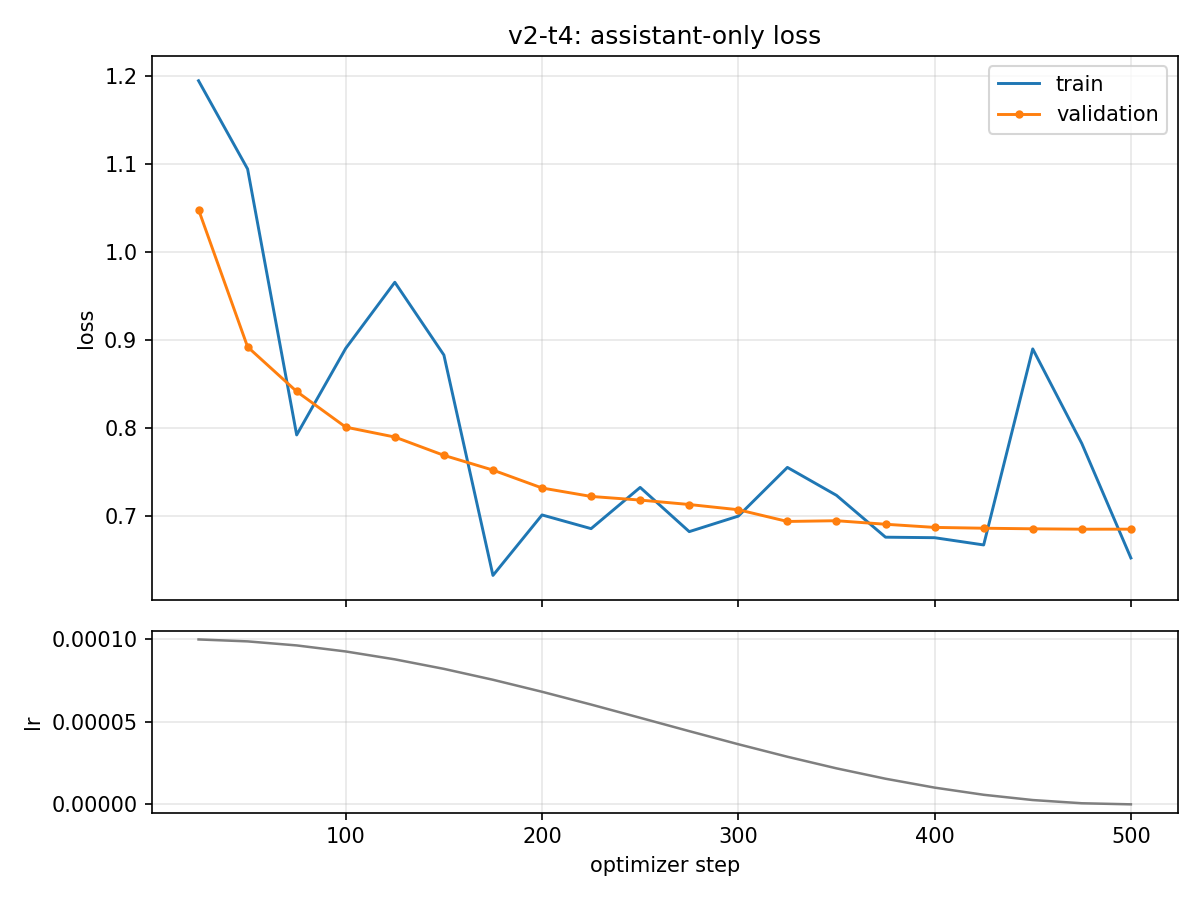

checking /content/ghl-support-slm/train/runs/v2-t4
loss.csv: 20 logged steps, 20 with a validation loss
peak memory: 2.94 GB (limit 12.0 GB)
git sha: 33bdbbd630bb45201a6dc1520e6243b0ad06eaea
reloading checkpoint-500 on cuda
sample answer:
I'm sorry to hear that you've forgotten your password and can't access your account. Don't worry, I'm here to guide you through the process of resetting it:
1. Visit our website's login page.
2. Look for the "Forgot Password" option on the top right corner.
3. Click on
PASS: run directory is complete and the adapter reloads
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
[python rc=0 32s]
{'run_n

In [9]:
run("python train/plot_curves.py train/runs/v2-t4")
from IPython.display import Image, display
display(Image("train/runs/v2-t4/curves.png", width=720))
run("python tools/training/check_run.py train/runs/v2-t4 --max-memory-gb 12")
c = json.load(open("train/runs/v2-t4/config.json"))
print({k: c.get(k) for k in ("run_name", "device", "git_sha", "final_step", "wall_s", "peak_memory_gb")})
run("tail -n 6 train/runs/v2-t4/loss.csv")

## 10. Dev answers for every checkpoint

Checkpoint selection is made on the 54-item dev set only, never on a sealed set (`docs/SELECTION.md`). Each checkpoint is merged into fp16, answers dev through the transformers backend, and the answers are kept with the run.

In [10]:
from pathlib import Path
run_dir = Path("train/runs/v2-t4")
ckpts = sorted((int(p.name.split("-")[1]), p) for p in run_dir.glob("checkpoint-*") if (p / "adapter_config.json").is_file())
print("checkpoints:", [s for s, _ in ckpts])
for step, folder in ckpts:
    out = run_dir / f"dev-checkpoint-{step}-raw.jsonl"
    shutil.rmtree("artifacts/merged", ignore_errors=True)
    run(f"python tools/artifacts/merge.py --adapter {folder} --output artifacts/merged", tail=1)
    run(f"python eval/run.py --model tuned --backend transformers --split dev --device cuda --output {out} --check-complete", tail=2)
shutil.rmtree("artifacts/merged", ignore_errors=True)

checkpoints: [100, 200, 250, 300, 400, 500]


Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
[python rc=0 88s]


    from eval.blind import sealed_hash
ModuleNotFoundError: No module named 'eval'
[python rc=1 0s]


SystemExit: 1

## 11. Package the run

Everything under `train/runs/v2-t4/` in one zip with its hash. The Mac side unpacks it, selects the checkpoint on dev, merges, quantizes to Q8, tags it in Ollama and scores it on the fresh sealed set.

In [11]:
archive = shutil.make_archive("/content/v2-t4", "zip", run_dir)
run(f"ls -la {archive} && sha256sum {archive}")
try:
    from google.colab import files; files.download(archive)
except Exception:
    print("not an interactive Colab kernel; download the zip with `colab download /content/v2-t4.zip <local>`")

-rw-r--r-- 1 root root 1225378342 Sep  7 22:10 /content/v2-t4.zip
8cf69a255c4bc440f100ce3979bdb8e97296da21d571e7140eb45becbd3fc724  /content/v2-t4.zip
[ls rc=0 6s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## What this run is, and is not

- It is the v2 headline training substrate if it finished clean here (gate above) and its artifacts reached the scoring machine in time; the rule was fixed before the run started.
- It is not the evaluation. The blind pass rate on the fresh sealed set comes from the sealed Ollama path on the Mac, judged by the frozen protocol, and is reported in `docs/RESULTS.md` beside v1's.

## Appendix: dev answers regenerated on this VM (04:00 to 04:31 IST)

```
prompt=/content/ghl-support-slm/artifacts/merged/prompt.txt
wrote=54 present=54 failures=0 output=train/runs/v2-t4/dev-checkpoint-100-raw.jsonl
CHECK PASS
prompt=/content/ghl-support-slm/artifacts/merged/prompt.txt
wrote=54 present=54 failures=0 output=train/runs/v2-t4/dev-checkpoint-200-raw.jsonl
CHECK PASS
prompt=/content/ghl-support-slm/artifacts/merged/prompt.txt
wrote=54 present=54 failures=0 output=train/runs/v2-t4/dev-checkpoint-250-raw.jsonl
CHECK PASS
prompt=/content/ghl-support-slm/artifacts/merged/prompt.txt
wrote=54 present=54 failures=0 output=train/runs/v2-t4/dev-checkpoint-300-raw.jsonl
CHECK PASS
prompt=/content/ghl-support-slm/artifacts/merged/prompt.txt
wrote=54 present=54 failures=0 output=train/runs/v2-t4/dev-checkpoint-400-raw.jsonl
CHECK PASS
prompt=/content/ghl-support-slm/artifacts/merged/prompt.txt
wrote=54 present=54 failures=0 output=train/runs/v2-t4/dev-checkpoint-500-raw.jsonl
CHECK PASS
DEVANS2 DONE
```
